# analysis_b / 04 — Daily Temporal Analysis

Two complementary views of how the corpus changes over time, both at **day-level** resolution:

**Part A — Daily normalized term frequency**  
Directly observable from the corpus. For each day and term: count ÷ total day tokens. No model required.

**Part B — Daily LDA topic prevalence**  
Mean theta loading per topic per day. Theta is the document-topic distribution output by LDA — each post's row sums to 1 and encodes how much of it belongs to each topic. Aggregating by day gives a smooth prevalence signal.

Both parts use OLS regression (`value ~ day_idx`) to detect linear trends, Bonferroni-corrected.

**Reads:** `artifacts/posts_clean.parquet`, `artifacts/theta.npy`, `artifacts/topic_labels.json`  
**Writes:** `artifacts/daily_term_freq.csv`, `artifacts/daily_topic_prevalence.csv`, `artifacts/term_regression_results.csv`, `artifacts/topic_regression_results.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from pathlib import Path
from collections import Counter
from scipy.stats import linregress

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

ARTIFACTS = Path('artifacts')

df = pd.read_parquet(ARTIFACTS / 'posts_clean.parquet')
print(f'Posts: {len(df):,}')

: 

## 0. Day-Level Time Index

In [2]:
# Use day_idx if already in parquet (written by 01_data.ipynb), else derive it
if 'day_idx' not in df.columns:
    df['date']    = pd.to_datetime(df['created_utc']).dt.normalize()
    df['day_idx'] = (df['date'] - df['date'].min()).dt.days
else:
    df['date'] = pd.to_datetime(df['created_utc']).dt.normalize()

date_min = df['date'].min()
date_max = df['date'].max()
n_days   = int(df['day_idx'].max()) + 1

day_table = df.groupby(['day_idx', 'date']).size().reset_index(name='n_posts')

print(f'Date range : {date_min.date()} → {date_max.date()}')
print(f'Total days : {n_days}')
print(f'Total posts: {len(df):,}')
print()
print(day_table.to_string(index=False))

Date range : 2026-02-19 → 2026-03-16
Total days : 26
Total posts: 5,369

 day_idx       date  n_posts
       0 2026-02-19       69
       1 2026-02-20      180
       2 2026-02-21      173
       3 2026-02-22      133
       4 2026-02-23      254
       5 2026-02-24      301
       6 2026-02-25      193
       7 2026-02-26      253
       8 2026-02-27      195
       9 2026-02-28      131
      10 2026-03-01      255
      11 2026-03-02      115
      12 2026-03-03      164
      13 2026-03-04      286
      14 2026-03-05      236
      15 2026-03-06      196
      16 2026-03-07      148
      17 2026-03-08      162
      18 2026-03-09      242
      19 2026-03-10      308
      20 2026-03-11      263
      21 2026-03-12      240
      22 2026-03-13      209
      23 2026-03-14      221
      24 2026-03-15      239
      25 2026-03-16      203


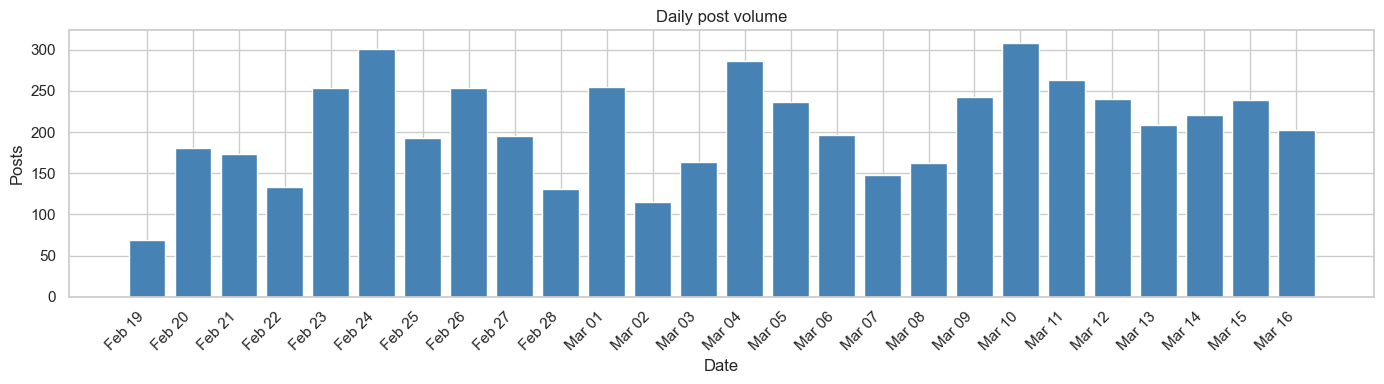

In [3]:
daily_vol = df.groupby('date').size().rename('posts').sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(daily_vol)), daily_vol.values, color='steelblue', width=0.8)
ax.set_xticks(range(len(daily_vol)))
ax.set_xticklabels([d.strftime('%b %d') for d in daily_vol.index], rotation=45, ha='right')
ax.set_title('Daily post volume')
ax.set_xlabel('Date')
ax.set_ylabel('Posts')
plt.tight_layout()
plt.show()

---
# Part A — Daily Normalized Term Frequency

For each day `d` and term `t`:

$$\text{freq}_{t,d} = \frac{\text{count of } t \text{ on day } d}{\text{total tokens on day } d}$$

Days with fewer than `MIN_TOKENS_DAY` total tokens are excluded.

In [4]:
TOP_N_TERMS    = 40
MIN_TOKENS_DAY = 100

all_tokens = [t for toks in df['tokens'] for t in toks]
term_freq  = Counter(all_tokens)
top_terms  = [t for t, _ in term_freq.most_common(TOP_N_TERMS)]

print(f'Tracking {len(top_terms)} terms: {top_terms}')

Tracking 40 terms: ['flair', 'see', 'thing', 'house', 'time', 'know', 'post', 'think', 'feel', 'remember', 'look', 'subreddit', 'experience', 'happen', 'people', 'year', 'like', 'read', 'get', 'room', 'question', 'change', 'say', 'mention', 'well', 'tell', 'night', 'contact', 'include', 'image', 'hear', 'come', 'expect', 'harm', 'remind', 'self', 'language', 'concern', 'bot', 'perform']


In [5]:
records = []
for (date, day_idx), grp in df.groupby(['date', 'day_idx']):
    day_tokens = [t for toks in grp['tokens'] for t in toks]
    total_toks = len(day_tokens)
    if total_toks < MIN_TOKENS_DAY:
        continue
    day_counts = Counter(day_tokens)
    row = {'date': date, 'day_idx': day_idx, 'total_tokens': total_toks}
    for term in top_terms:
        row[term] = day_counts.get(term, 0) / total_toks
    records.append(row)

daily_tf = pd.DataFrame(records).sort_values('day_idx').reset_index(drop=True)

print(f'Days retained: {len(daily_tf)} / {n_days}  (excluded {n_days - len(daily_tf)} below token floor)')
daily_tf[['date', 'day_idx', 'total_tokens'] + top_terms[:5]].head()

Days retained: 26 / 26  (excluded 0 below token floor)


,date,day_idx,total_tokens,flair,see,thing,house,time
0,2026-02-19,0,2894,0.012440,0.005529,0.004147,0.003801,0.007947
1,2026-02-20,1,8082,0.006187,0.007300,0.004578,0.003093,0.008661
2,2026-02-21,2,6953,0.010643,0.008486,0.007047,0.005753,0.008629
3,2026-02-22,3,4874,0.011490,0.008207,0.005950,0.007591,0.006155
4,2026-02-23,4,10662,0.007034,0.008723,0.007691,0.010598,0.007972


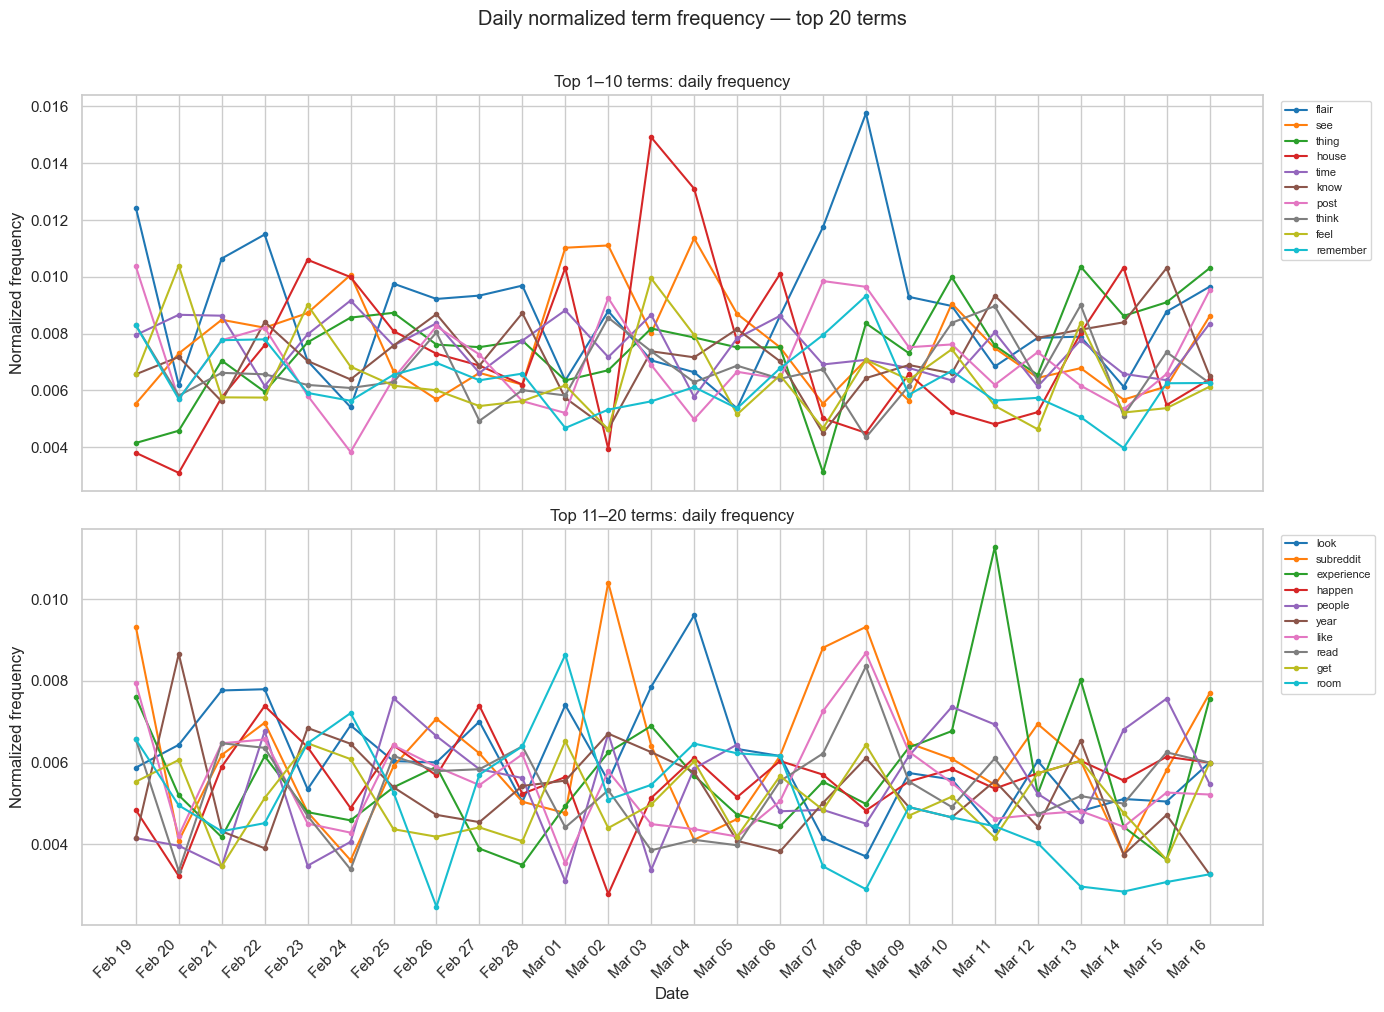

In [6]:
x      = daily_tf['day_idx'].values
x_labels = [d.strftime('%b %d') for d in daily_tf['date']]
cmap   = plt.cm.tab20

PANEL_TERMS = top_terms[:20]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for panel, (ax, terms_slice) in enumerate(zip(axes, [PANEL_TERMS[:10], PANEL_TERMS[10:]])):
    for i, term in enumerate(terms_slice):
        ax.plot(x, daily_tf[term], label=term,
                color=cmap(i / 10), linewidth=1.5, marker='o', markersize=3)
    ax.set_ylabel('Normalized frequency')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.set_title(f'Top {panel * 10 + 1}–{panel * 10 + len(terms_slice)} terms: daily frequency')

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[-1].set_xlabel('Date')
plt.suptitle('Daily normalized term frequency — top 20 terms', y=1.01)
plt.tight_layout()
plt.show()

### A.1 OLS Regression per Term

In [7]:
alpha_bonf_terms = 0.05 / len(top_terms)
day_vals         = daily_tf['day_idx'].values.astype(float)
term_reg         = []

for term in top_terms:
    slope, intercept, r, p, se = linregress(day_vals, daily_tf[term].values)
    term_reg.append({'term': term, 'slope': slope, 'r_squared': r**2,
                     'p_value': p, 'se': se, 'sig': p < alpha_bonf_terms})

term_reg_df = pd.DataFrame(term_reg).sort_values('slope', ascending=False).reset_index(drop=True)

print(f'Bonferroni threshold : p < {alpha_bonf_terms:.4f}')
print(f'Significant terms    : {term_reg_df["sig"].sum()} / {len(top_terms)}')
print()
print(term_reg_df[['term', 'slope', 'r_squared', 'p_value', 'sig']].to_string(index=False))

Bonferroni threshold : p < 0.0013
Significant terms    : 0 / 40

      term     slope  r_squared  p_value   sig
     thing  0.000115   0.259055 0.007921 False
    people  0.000069   0.141631 0.058103 False
experience  0.000051   0.055318 0.247432 False
      know  0.000046   0.066836 0.202236 False
  question  0.000021   0.018494 0.507712 False
     think  0.000016   0.010570 0.617231 False
      read  0.000015   0.010404 0.620027 False
    happen  0.000014   0.011522 0.601715 False
 subreddit  0.000011   0.002187 0.820548 False
      post  0.000009   0.001611 0.845636 False
    change  0.000008   0.002333 0.814734 False
      well  0.000005   0.001167 0.868425 False
      come  0.000005   0.001111 0.871612 False
    expect  0.000002   0.000128 0.956220 False
       get -0.000002   0.000212 0.943724 False
   mention -0.000003   0.000489 0.914568 False
     house -0.000004   0.000100 0.961385 False
     image -0.000004   0.000705 0.897557 False
      harm -0.000004   0.000797 0.891108 F

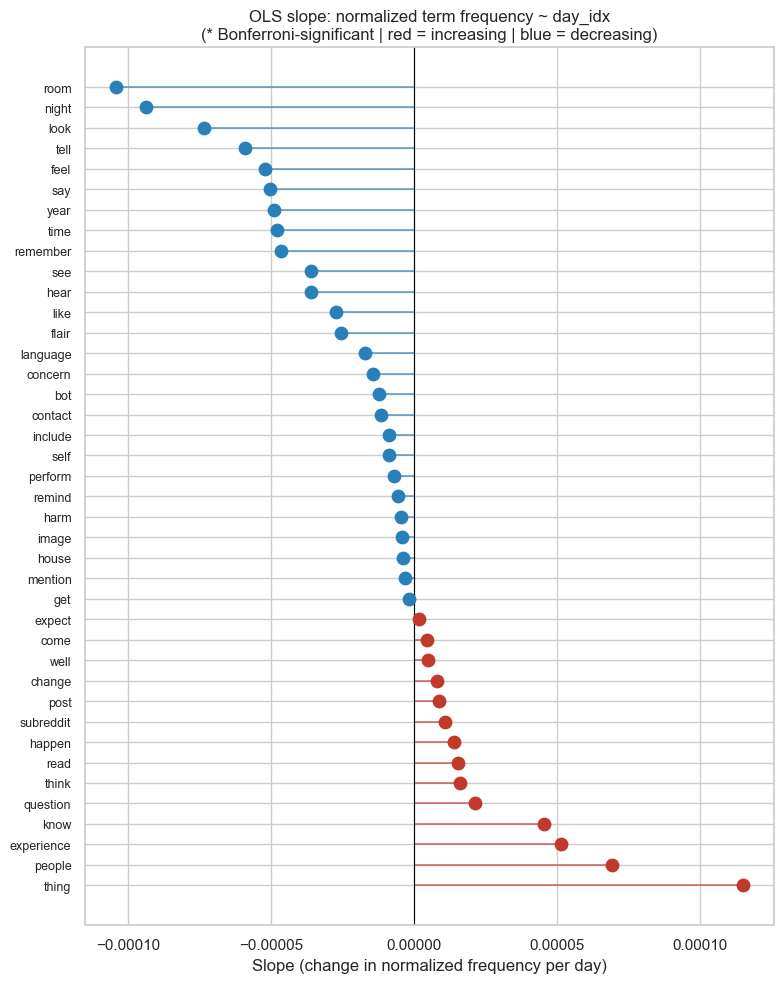

In [8]:
fig, ax = plt.subplots(figsize=(8, 10))
for i, (_, row) in enumerate(term_reg_df.iterrows()):
    color  = '#c0392b' if row['slope'] > 0 else '#2980b9'
    marker = '*' if row['sig'] else 'o'
    ax.scatter(row['slope'], i, color=color, s=80, marker=marker, zorder=3)
    ax.hlines(i, 0, row['slope'], color=color, linewidth=1.2, alpha=0.7)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(range(len(term_reg_df)))
ax.set_yticklabels(term_reg_df['term'], fontsize=9)
ax.set_title('OLS slope: normalized term frequency ~ day_idx\n(* Bonferroni-significant | red = increasing | blue = decreasing)')
ax.set_xlabel('Slope (change in normalized frequency per day)')
plt.tight_layout()
plt.show()

### A.2 Term Frequency Heatmap (z-scored per term)

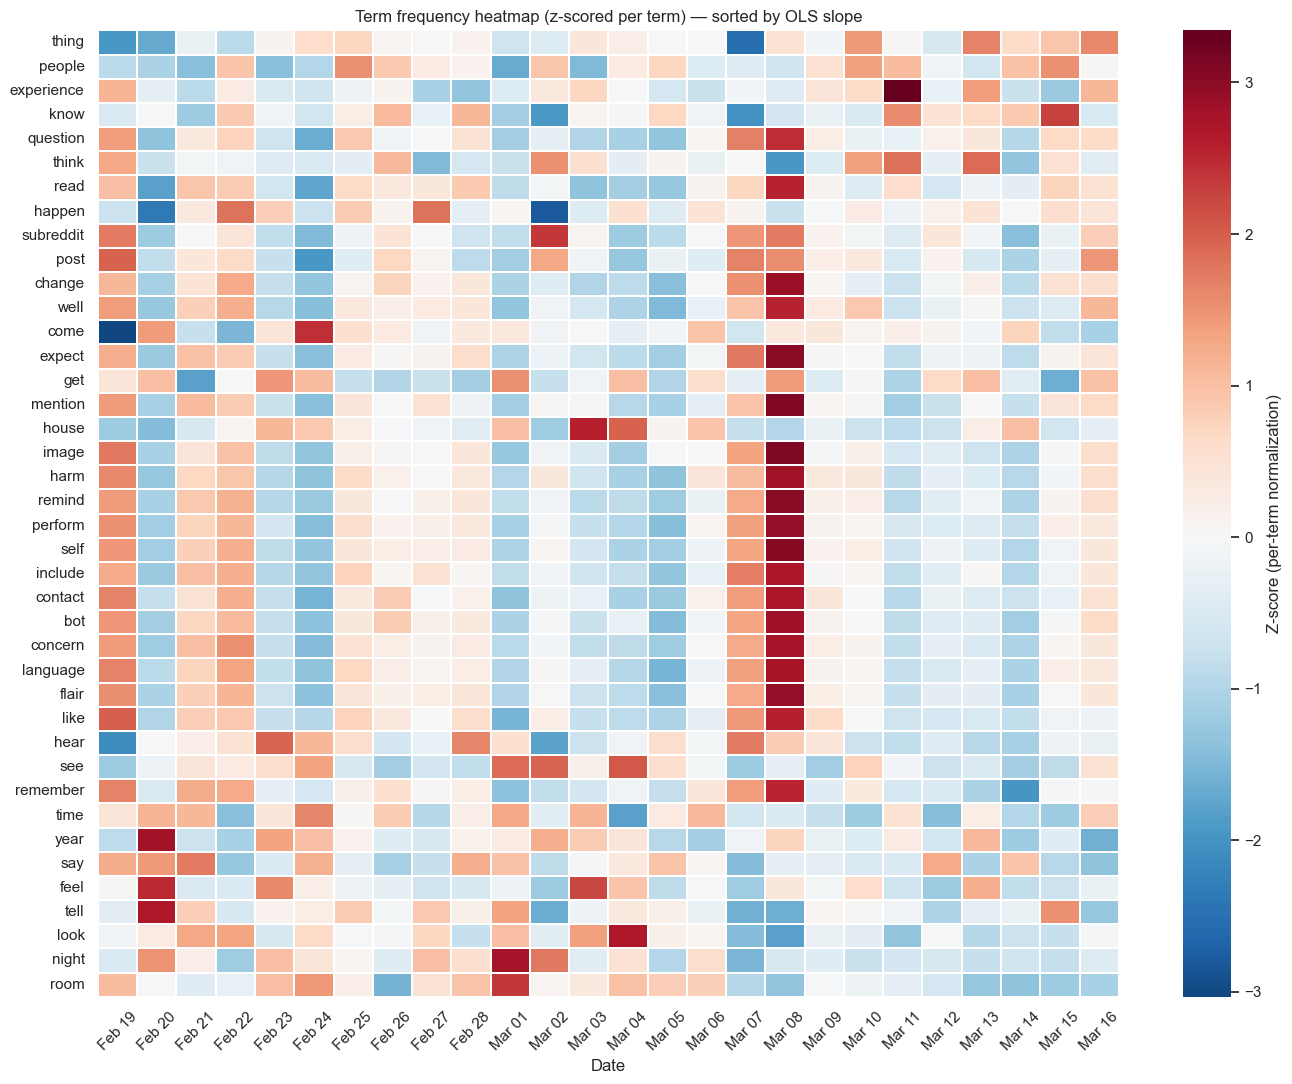

In [9]:
heat_mat  = daily_tf[top_terms].T
row_mean  = heat_mat.mean(axis=1)
row_std   = heat_mat.std(axis=1).replace(0, 1)
heat_z    = heat_mat.subtract(row_mean, axis=0).divide(row_std, axis=0)
term_order = term_reg_df['term'].tolist()
heat_z     = heat_z.loc[term_order]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    heat_z, ax=ax, cmap='RdBu_r', center=0, linewidths=0.3,
    xticklabels=x_labels,
    yticklabels=term_order,
    cbar_kws={'label': 'Z-score (per-term normalization)'},
)
ax.set_title('Term frequency heatmap (z-scored per term) — sorted by OLS slope')
ax.set_xlabel('Date')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
# Part B — Daily LDA Topic Prevalence

**Theta** (`theta.npy`) is the (N posts × K topics) document-topic matrix from LDA. Each row sums to 1. Aggregating by day gives the mean proportion of each topic in that day's posts.

Make sure `03_lda.ipynb` has been run first.

In [10]:
theta = np.load(ARTIFACTS / 'theta.npy')

with open(ARTIFACTS / 'topic_labels.json') as fh:
    topic_labels = json.load(fh)

K_FINAL = theta.shape[1]

print(f'theta shape : {theta.shape}  (posts × topics)')
print(f'K           : {K_FINAL}')
print()
print('Topic labels:')
for k in range(K_FINAL):
    print(f'  {k:2d}: {topic_labels.get(str(k), f"Topic {k}")}')

theta shape : (5369, 4)  (posts × topics)
K           : 4

Topic labels:
   0: Topic 0 — label here
   1: Topic 1 — label here
   2: Topic 2 — label here
   3: Topic 3 — label here


In [11]:
# Attach theta to df
topic_cols = [f'topic_{k}' for k in range(K_FINAL)]
theta_df   = pd.DataFrame(theta, columns=topic_cols, index=df.index)
df_theta   = pd.concat([df[['date', 'day_idx']], theta_df], axis=1)

# Daily mean theta per topic
daily_theta = df_theta.groupby(['day_idx', 'date'])[topic_cols].mean().reset_index()
daily_theta = daily_theta.sort_values('day_idx').reset_index(drop=True)

print(f'Daily theta shape: {daily_theta.shape}')
daily_theta.head()

Daily theta shape: (26, 6)


,day_idx,date,topic_0,topic_1,topic_2,topic_3
0,0,2026-02-19,0.383210,0.292289,0.264028,0.060473
1,1,2026-02-20,0.567734,0.256160,0.145616,0.030490
2,2,2026-02-21,0.469766,0.273971,0.220376,0.035887
3,3,2026-02-22,0.396621,0.351786,0.217298,0.034294
4,4,2026-02-23,0.527157,0.281419,0.154861,0.036563


### B.1 Topic Prevalence Line Plot

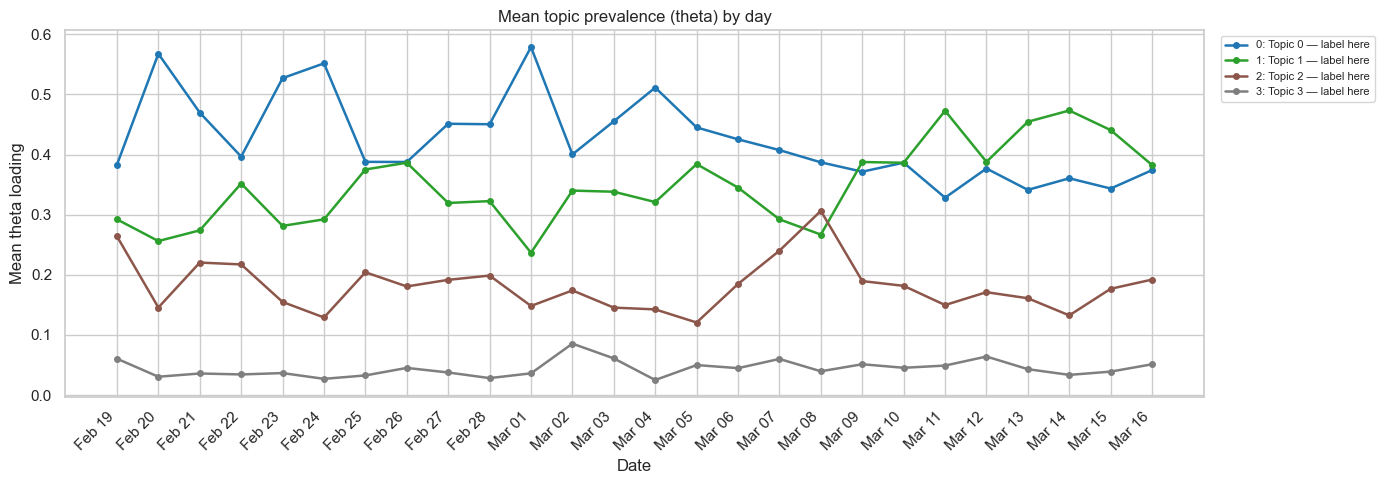

In [12]:
xt       = daily_theta['day_idx'].values
xt_labels = [d.strftime('%b %d') for d in daily_theta['date']]
cmap_k   = plt.cm.tab10

fig, ax = plt.subplots(figsize=(14, 5))
for k in range(K_FINAL):
    col   = f'topic_{k}'
    label = topic_labels.get(str(k), f'Topic {k}')
    ax.plot(xt, daily_theta[col], label=f'{k}: {label}',
            color=cmap_k(k / K_FINAL), linewidth=1.8, marker='o', markersize=4)

ax.set_xticks(xt)
ax.set_xticklabels(xt_labels, rotation=45, ha='right')
ax.set_title('Mean topic prevalence (theta) by day')
ax.set_xlabel('Date')
ax.set_ylabel('Mean theta loading')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### B.2 OLS Regression per Topic

In [13]:
alpha_bonf_topics = 0.05 / K_FINAL
day_vals_t        = daily_theta['day_idx'].values.astype(float)
topic_reg         = []

for k in range(K_FINAL):
    col                       = f'topic_{k}'
    label                     = topic_labels.get(str(k), f'Topic {k}')
    slope, intercept, r, p, se = linregress(day_vals_t, daily_theta[col].values)
    topic_reg.append({
        'topic'    : k,
        'label'    : label,
        'slope'    : slope,
        'r_squared': r ** 2,
        'p_value'  : p,
        'se'       : se,
        'sig'      : p < alpha_bonf_topics,
    })

topic_reg_df = pd.DataFrame(topic_reg).sort_values('slope', ascending=False).reset_index(drop=True)

print(f'Bonferroni threshold : p < {alpha_bonf_topics:.4f}')
print(f'Significant topics   : {topic_reg_df["sig"].sum()} / {K_FINAL}')
print()
cols = ['topic', 'label', 'slope', 'r_squared', 'p_value', 'sig']
print(topic_reg_df[cols].to_string(index=False))

Bonferroni threshold : p < 0.0125
Significant topics   : 2 / 4

 topic                label     slope  r_squared  p_value   sig
     1 Topic 1 — label here  0.005913   0.466438 0.000121  True
     3 Topic 3 — label here  0.000429   0.056069 0.244154 False
     2 Topic 2 — label here -0.000774   0.018970 0.502237 False
     0 Topic 0 — label here -0.005568   0.357725 0.001250  True


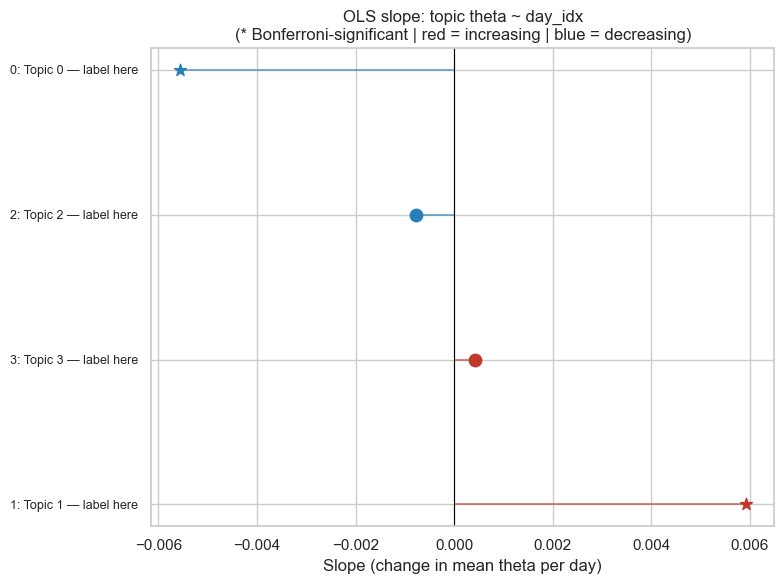

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, (_, row) in enumerate(topic_reg_df.iterrows()):
    color  = '#c0392b' if row['slope'] > 0 else '#2980b9'
    marker = '*' if row['sig'] else 'o'
    ax.scatter(row['slope'], i, color=color, s=80, marker=marker, zorder=3)
    ax.hlines(i, 0, row['slope'], color=color, linewidth=1.2, alpha=0.7)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(range(len(topic_reg_df)))
ax.set_yticklabels(
    [f"{int(r['topic'])}: {r['label']}" for _, r in topic_reg_df.iterrows()], fontsize=9
)
ax.set_title('OLS slope: topic theta ~ day_idx\n(* Bonferroni-significant | red = increasing | blue = decreasing)')
ax.set_xlabel('Slope (change in mean theta per day)')
plt.tight_layout()
plt.show()

### B.3 Topic Prevalence Heatmap (z-scored per topic)

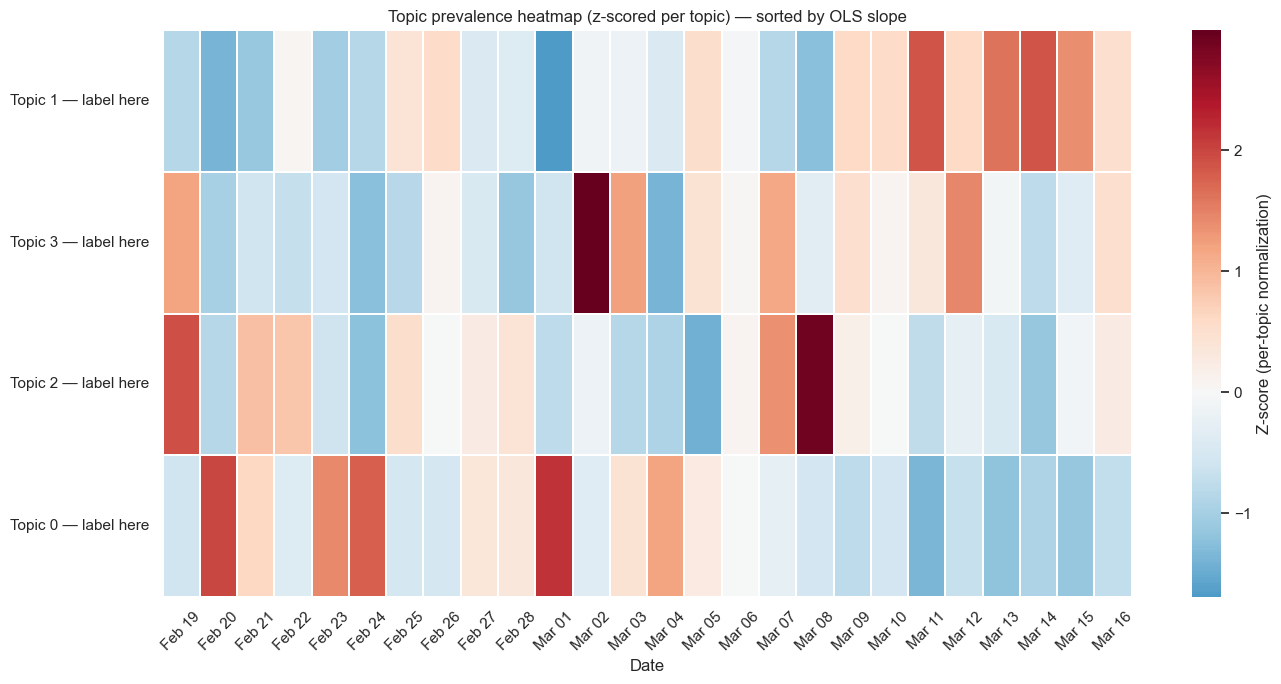

In [15]:
heat_t    = daily_theta[topic_cols].T  # (K, days)
heat_t.index = [topic_labels.get(str(k), f'Topic {k}') for k in range(K_FINAL)]

row_mean_t = heat_t.mean(axis=1)
row_std_t  = heat_t.std(axis=1).replace(0, 1)
heat_tz    = heat_t.subtract(row_mean_t, axis=0).divide(row_std_t, axis=0)

# Sort by OLS slope
topic_order = [
    topic_labels.get(str(int(r['topic'])), f'Topic {int(r["topic"])}')
    for _, r in topic_reg_df.iterrows()
]
heat_tz = heat_tz.loc[topic_order]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heat_tz, ax=ax, cmap='RdBu_r', center=0, linewidths=0.3,
    xticklabels=xt_labels,
    cbar_kws={'label': 'Z-score (per-topic normalization)'},
)
ax.set_title('Topic prevalence heatmap (z-scored per topic) — sorted by OLS slope')
ax.set_xlabel('Date')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Write Artifacts

In [ ]:
daily_tf.to_csv(ARTIFACTS / 'daily_term_freq.csv', index=False)
daily_theta.to_csv(ARTIFACTS / 'daily_topic_prevalence.csv', index=False)
term_reg_df.to_csv(ARTIFACTS / 'term_regression_results.csv', index=False)
topic_reg_df.to_csv(ARTIFACTS / 'topic_regression_results.csv', index=False)

print('Written:')
for name in ('daily_term_freq.csv', 'daily_topic_prevalence.csv',
             'term_regression_results.csv', 'topic_regression_results.csv'):
    p = ARTIFACTS / name
    print(f'  {p}  ({p.stat().st_size / 1024:.1f} KB)')

## Observations

*(Fill in after running all cells.)*

**Part A — Term frequency trends:**
- Significant terms (increasing):
- Significant terms (decreasing):
- Heatmap clusters:

**Part B — Topic prevalence trends:**
- Significant topics (increasing):
- Significant topics (decreasing):
- Overall pattern:

**Limitations:**
- Short window (~25 days) — trends are exploratory, not confirmatory
- OLS assumes independent observations (no autocorrelation correction)
- Theta values are LDA estimates, not fixed observations — uncertainty is not propagated
